# CyberNova Analytics – CRISP-DM Phase 3: Modelling
## BSc Business Intelligence & Data Analytics | CET333 Product Development

**Student:** Mmopiemang Mmopiemang
**Grounded in:** *Business Intelligence, Analytics, and Data Science: A Managerial Perspective* (Sharda, Delen & Turban)
- Chapter 4 – Predictive Analytics I: CRISP-DM Model Building, Testing, Evaluation

### Phase Objectives
| Deliverable | REQ(s) |
|-------------|--------|
| OLS Regression benchmark – coefficients, R², p-values | REQ-11 |
| DoWhy causal model – DAG, backdoor identification, ATE | REQ-11 |
| Refutation tests – placebo treatment + random common cause | REQ-11 |
| Model comparison report – effect size, CI, interpretability | REQ-11 |
| DuckDB SQL query library – all dashboard analytical components | REQ-05 to REQ-13 |
| Anomaly threshold logic | REQ-12, REQ-14 |
| Export: model_comparison_report.md + all df variants as CSV | Portfolio |

### Modelling Strategy
OLS is built first as a quantitative benchmark. Without a baseline, the added
complexity of DoWhy cannot be analytically justified. DoWhy is selected as the
primary model because REQ-11 demands a causal claim, not a correlation. The refutation API provides robustness verification that OLS cannot.

In [9]:
import os
print(os.getcwd())
print(os.listdir('.'))  # listing all files in the current folder


c:\Users\bida22-038\cyber_draft\dashboard\notebooks
['fig_anomaly_threshold.png', 'fig_ensemble_results.png', 'fig_ols_coefficients.png', 'modelling_notebook.ipynb']


In [10]:
import os
print(os.getcwd())

c:\Users\bida22-038\cyber_draft\dashboard\notebooks


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
import os
import json
from pathlib import Path
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor":  "#0D1117",
    "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D",
    "axes.labelcolor":   "#C9D1D9",
    "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E",
    "text.color":        "#C9D1D9",
    "grid.color":        "#21262D",
    "grid.linestyle":    "--",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
})
CYBERNOVA_PALETTE = ["#58A6FF", "#3FB950", "#F78166", "#D2A8FF", "#FFA657"]
SERVICES = [
    "AI Cyber Assistant", "Network Security Audit",
    "Penetration Testing", "Schedule Demo", "Cyber Awareness Webinar",
]

CSV_PATH = Path('..') / ('..') / 'data' / 'cybernova_iis_logs_messy.csv'
df_raw = pd.read_csv(CSV_PATH, low_memory=False)

# replicating the EDA cleaning pipeline
COUNTRY_CANON = {
    "BW": "Botswana",     "botswana": "Botswana",    "Botswana ": "Botswana",   "B.W.": "Botswana",
    "SA": "South Africa", "ZA": "South Africa",      "south africa": "South Africa", "S.Africa": "South Africa",
    "ZW": "Zimbabwe",     "zimbabwe": "Zimbabwe",    "Zimbabwe ": "Zimbabwe",
    "ZM": "Zambia",       "zambia": "Zambia",
    "NA": "Namibia",      "namibia": "Namibia",
}
df = df_raw.copy()
df["client-country"] = df["client-country"].replace(COUNTRY_CANON)
df["timestamp"]      = pd.to_datetime(df["date"] + " " + df["time"], errors="coerce")
df                   = df.dropna(subset=["timestamp"])
df["time-taken"]     = pd.to_numeric(df["time-taken"], errors="coerce")
df["sc-bytes"]       = df["sc-bytes"].apply(lambda x: float(str(x).replace(",","")) if pd.notna(x) else np.nan)
df["cs-uri-stem"]    = df["cs-uri-stem"].str.strip()
df["cs-method"]      = df["cs-method"].str.upper()
df["c-ip"]           = df["c-ip"].fillna("Unknown")
df["conversion_flag"]= df["conversion_flag"].fillna(0).astype(int)
df["ai_chat_engaged"]= df["ai_chat_engaged"].fillna(0).astype(int)

df_sales = df[df["funnel_stage"].isin(["awareness","interest","consideration","conversion"])].copy()
STAGE_DEPTH = {"awareness": 1, "interest": 2, "consideration": 3, "conversion": 4}

df_sessions = (
    df_sales.groupby("session_id")
    .agg(
        service_type    = ("service_type",   "first"),
        country         = ("client-country",  "first"),
        city            = ("client-city",      "first"),
        session_date    = ("date",            "first"),
        hour_of_day     = ("hour_of_day",     "first"),
        day_of_week     = ("day_of_week",     "first"),
        converted       = ("conversion_flag", "max"),
        ai_chat_engaged = ("ai_chat_engaged", "max"),
        page_hits       = ("session_id",       "count"),
        funnel_depth    = ("funnel_stage",     lambda s: s.map(STAGE_DEPTH).max()),
    )
    .reset_index()
)
df_sessions["session_date"] = pd.to_datetime(df_sessions["session_date"])

daily_demos = (
    df_sessions.groupby(["session_date","service_type"])
    .agg(requests=("session_id","count"), conversions=("converted","sum"))
    .reset_index()
)

print(f"Sessions loaded : {len(df_sessions):,}")
print(f"Date range      : {df_sessions['session_date'].min().date()} to {df_sessions['session_date'].max().date()}")
print(f"Services        : {df_sessions['service_type'].nunique()}")

Sessions loaded : 297,575
Date range      : 2026-02-06 to 2026-04-06
Services        : 5


## 1. Feature Engineering for Modelling

Before fitting any model, the modelling dataframe is constructed with:
- **Treatment**: `ai_chat_engaged` (binary :1 if session engaged the AI chatbot)
- **Outcome**: `converted` (binary : 1 if session reached /scheduledemo.php)
- **Confounders**: `service_enc`, `country_enc`, `hour_of_day`, `daily_request_volume`, `funnel_depth`
- **Derived features**:
  - `daily_request_volume` - total sessions for this service on this day (demand context)
  - `funnel_depth` - max funnel stage reached (1=awareness → 4=conversion); captures selection bias where deeper-funnel sessions are both more likely to engage the chatbot AND more likely to convert
  - `page_hits_log` -  log-transformed page hit count; reduces right skew from long sessions
  - `is_weekend` - binary flag; weekend traffic has distinct conversion patterns
  - `hour_bin` - ordinal grouping of hour_of_day into 4 business periods (night/morning/afternoon/evening)
  - `vol_x_depth` - interaction term: daily_request_volume × funnel_depth; captures whether high-demand days amplify funnel progression effects

In [12]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd


cols_to_clean = ["daily_request_volume", "rolling_7d_conv_rate"]
df_sessions = df_sessions.drop(columns=[c for c in cols_to_clean if c in df_sessions.columns])

# using a join on a MultiIndex
volume_lookup = (
    daily_demos.groupby(["session_date", "service_type"])["requests"]
    .first()
    .rename("daily_request_volume")
)
df_sessions = df_sessions.join(volume_lookup, on=["session_date", "service_type"])
df_sessions["daily_request_volume"] = df_sessions["daily_request_volume"].fillna(0)

df_sessions["page_hits_log"] = np.log1p(df_sessions["page_hits"])
df_sessions["is_weekend"]    = df_sessions["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

def hour_to_bin(h):
    if h < 6:  return 0 
    if h < 12: return 1 
    if h < 18: return 2 
    return 3 

df_sessions["hour_bin"]    = df_sessions["hour_of_day"].apply(hour_to_bin)
df_sessions["vol_x_depth"] = df_sessions["daily_request_volume"] * df_sessions["funnel_depth"]

df_sessions["session_date"] = pd.to_datetime(df_sessions["session_date"])
daily_conv = (
    df_sessions.groupby(["service_type", "session_date"])["converted"]
    .mean()
    .reset_index()
    .sort_values("session_date")
)


#daily_conv["rolling_7d_conv_rate"] = (
#    daily_conv.groupby("service_type")
#    .rolling(window="7D", on="session_date")["converted"]
#    .mean()
#    .reset_index(level=0, drop=True)
#)

#df_sessions = df_sessions.merge(
#    daily_conv[["service_type", "session_date", "rolling_7d_conv_rate"]],
#    on=["service_type", "session_date"],
#    how="left"
#)

df_sessions["depth_per_hit"] = df_sessions["funnel_depth"] / (df_sessions["page_hits"] + 1)
df_sessions["ai_x_depth"]    = df_sessions["ai_chat_engaged"] * df_sessions["funnel_depth"]

svc_mean = df_sessions.groupby("service_type")["daily_request_volume"].transform("mean")
svc_std  = df_sessions.groupby("service_type")["daily_request_volume"].transform("std").replace(0, 1)
df_sessions["demand_zscore"] = (df_sessions["daily_request_volume"] - svc_mean) / svc_std

ALL_FEATURES = [
    "session_id", "converted", "ai_chat_engaged",
    "service_type", "country", "hour_of_day",
    "daily_request_volume", "funnel_depth",
    "page_hits_log", "is_weekend", "hour_bin", "vol_x_depth",
     "depth_per_hit", "ai_x_depth", "demand_zscore",
] #"rolling_7d_conv_rate",

df_model = df_sessions[ALL_FEATURES].dropna().copy()

le_svc = LabelEncoder()
le_cty = LabelEncoder()
df_model["service_enc"] = le_svc.fit_transform(df_model["service_type"])
df_model["country_enc"] = le_cty.fit_transform(df_model["country"])

# causal dataframe
df_causal = df_model[[
    "converted", "ai_chat_engaged",
    "service_enc", "country_enc", "hour_of_day",
    "daily_request_volume", "funnel_depth",
]].copy()

print(f"Modelling rows  : {len(df_model):,}")
print(f"Conversion rate : {df_model['converted'].mean()*100:.2f}%")
print(f"AI chat rate    : {df_model['ai_chat_engaged'].mean()*100:.2f}%")
print(f"\nFull feature set ({len(ALL_FEATURES)-3} predictors):")
display(df_model[[
    "converted", "ai_chat_engaged", "service_enc", "country_enc",
    "hour_of_day", "daily_request_volume", "funnel_depth",
    "page_hits_log", "is_weekend", "hour_bin", "vol_x_depth",
   "depth_per_hit", "ai_x_depth", "demand_zscore",
]].describe().round(3)) # "rolling_7d_conv_rate"

Modelling rows  : 297,372
Conversion rate : 21.96%
AI chat rate    : 16.38%

Full feature set (12 predictors):


,converted,ai_chat_engaged,service_enc,country_enc,hour_of_day,daily_request_volume,funnel_depth,page_hits_log,is_weekend,hour_bin,vol_x_depth,depth_per_hit,ai_x_depth,demand_zscore
count,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000,297372.000
mean,0.220,0.164,2.080,1.533,13.108,1186.232,1.789,0.986,0.299,1.744,2141.497,0.616,0.410,-0.000
std,0.414,0.370,1.427,1.477,4.146,287.252,0.780,0.269,0.458,0.737,1150.770,0.106,0.982,1.000
min,0.000,0.000,0.000,0.000,0.000,130.000,1.000,0.693,0.000,0.000,130.000,0.500,0.000,-4.065
25%,0.000,0.000,1.000,0.000,10.000,978.000,1.000,0.693,0.000,1.000,1251.000,0.500,0.000,-0.665
50%,0.000,0.000,2.000,2.000,13.000,1240.000,2.000,1.099,0.000,2.000,1852.000,0.667,0.000,0.121
75%,0.000,0.000,3.000,3.000,16.000,1350.000,2.000,1.099,1.000,2.000,2762.000,0.667,0.000,0.731
max,1.000,1.000,4.000,4.000,23.000,1720.000,4.000,1.609,1.000,3.000,6552.000,1.333,4.000,1.960


## 2. OLS Regression Benchmark

OLS is fitted first. It is not the intended solution but as a necessary
quantitative benchmark. Without it, the added complexity of DoWhy cannot
be analytically justified (CRISP-DM Model Building, Ch. 4).

**Model specification:**
`converted ~ ai_chat_engaged + daily_request_volume + service_enc + country_enc + hour_of_day`

Limitations recorded here are the analytical motivation for the causal model:
- OLS assumes no unmeasured confounding
- Coefficients are associational, not causal
- R² on a binary outcome is descriptive only

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

OLS_FEATURES = [
    "ai_chat_engaged", "daily_request_volume",
    "service_enc", "country_enc", "hour_of_day",
    "funnel_depth", "page_hits_log", "is_weekend", "hour_bin", "vol_x_depth",
     "depth_per_hit", "ai_x_depth", "demand_zscore",
] #"rolling_7d_conv_rate",

X_ols = sm.add_constant(df_model[OLS_FEATURES])
y_ols = df_model["converted"]

ols_model = sm.OLS(y_ols, X_ols).fit()
ols_coef  = ols_model.params["ai_chat_engaged"]
ols_ci    = ols_model.conf_int().loc["ai_chat_engaged"]
ols_pval  = ols_model.pvalues["ai_chat_engaged"]
ols_r2    = ols_model.rsquared

print("OLS Regression Benchmark — Extended Feature Set\n")
print(f"  R²                          : {ols_r2:.4f}")
print(f"  ai_chat_engaged coefficient : {ols_coef:.4f}")
print(f"  95% Confidence Interval     : [{ols_ci[0]:.4f}, {ols_ci[1]:.4f}]")
print(f"  p-value                     : {ols_pval:.6f}")
print(f"  Effect size (pp)            : {ols_coef*100:.2f} pp")
print(f"\n  All coefficients:")
coef_df = pd.DataFrame({
    "coef": ols_model.params,
    "se":   ols_model.bse,
    "p":    ols_model.pvalues,
}).round(4)
display(coef_df)

ols_cv = cross_val_score(
    LinearRegression(), X_ols.values, y_ols.values, cv=5, scoring="r2"
)
print(f"\n  5-fold CV R²: {ols_cv.mean():.4f} ± {ols_cv.std():.4f}")

ols_results = {
    "model":          "OLS Regression",
    "effect_pp":      round(ols_coef * 100, 3),
    "ci_lower":       round(ols_ci[0] * 100, 3),
    "ci_upper":       round(ols_ci[1] * 100, 3),
    "p_value":        round(ols_pval, 6),
    "r_squared":      round(ols_r2, 4),
    "cv_r2_mean":     round(ols_cv.mean(), 4),
    "causal":         False,
    "refuted":        False,
    "interpretation": "Associational — confounding not fully controlled",
}

OLS Regression Benchmark — Extended Feature Set

  R²                          : 0.5320
  ai_chat_engaged coefficient : 0.0479
  95% Confidence Interval     : [0.0382, 0.0576]
  p-value                     : 0.000000
  Effect size (pp)            : 4.79 pp

  All coefficients:


,coef,se,p
const,0.4595,0.0100,0.0000
ai_chat_engaged,0.0479,0.0050,0.0000
daily_request_volume,0.0001,0.0000,0.0000
service_enc,0.0362,0.0004,0.0000
country_enc,0.0008,0.0004,0.0170
hour_of_day,-0.0002,0.0003,0.5184
funnel_depth,1.3154,0.0064,0.0000
page_hits_log,-1.1954,0.0128,0.0000
is_weekend,0.0011,0.0011,0.3353
hour_bin,0.0026,0.0019,0.1722



  5-fold CV R²: 0.5320 ± 0.0018


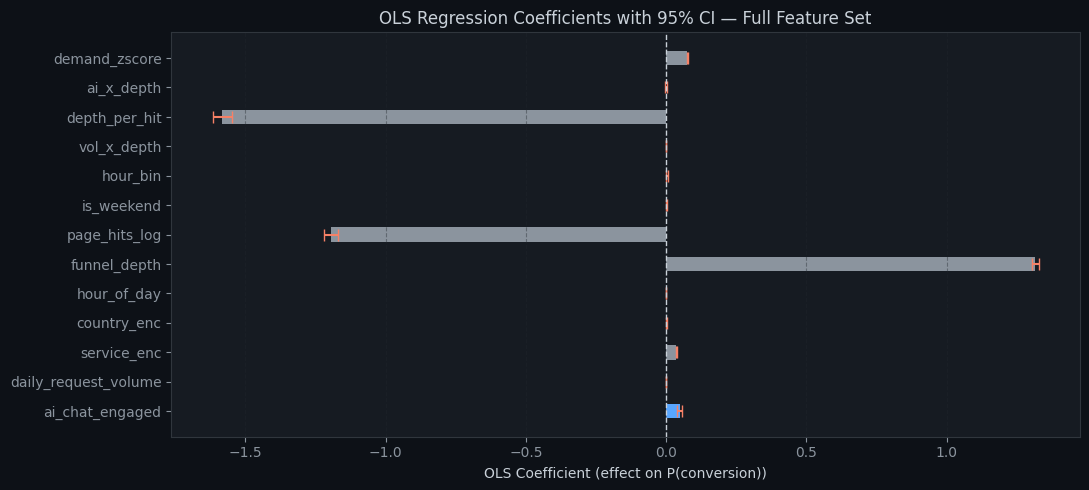

Treatment variable (ai_chat_engaged) highlighted in blue.


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
coefs  = ols_model.params[OLS_FEATURES]
errors = ols_model.bse[OLS_FEATURES]
colours = ["#58A6FF" if f == "ai_chat_engaged" else "#8B949E" for f in OLS_FEATURES]
ax.barh(OLS_FEATURES, coefs, xerr=errors * 1.96, color=colours,
        height=0.5, ecolor="#F78166", capsize=4)
ax.axvline(0, color="#C9D1D9", linewidth=1, linestyle="--")
ax.set_xlabel("OLS Coefficient (effect on P(conversion))")
ax.set_title("OLS Regression Coefficients with 95% CI — Full Feature Set")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_ols_coefficients.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("Treatment variable (ai_chat_engaged) highlighted in blue.")

## Polynomial Regression
Polynomial Regression (degree-2)
**Motivation (Sharda et al., Ch. 4):**

when relationships between features and outcome are non-linear, polynomial terms capture curvature that OLS misses. Here I add degree-2 terms for the two continuous confounders (funnel_depth, daily_request_volume) and the interaction already engineered (vol_x_depth). ai_chat_engaged remains linear. it is binary so squaring it is identical to the original. R² change vs OLS quantifies the marginal value of allowing non-linearity.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

POLY_CONTINUOUS = [
    "funnel_depth", "daily_request_volume", "page_hits_log",
    "hour_bin", "depth_per_hit", "demand_zscore",
] # "rolling_7d_conv_rate",
POLY_LINEAR = [
    "ai_chat_engaged", "service_enc", "country_enc",
    "is_weekend", "vol_x_depth", "ai_x_depth",
]

X_continuous = df_model[POLY_CONTINUOUS].values
X_linear     = df_model[POLY_LINEAR].values
y_poly       = df_model["converted"].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_expanded    = poly.fit_transform(X_continuous)
poly_feature_names = poly.get_feature_names_out(POLY_CONTINUOUS).tolist()

X_poly_full    = np.hstack([X_poly_expanded, X_linear])
all_poly_names = poly_feature_names + POLY_LINEAR

X_poly_sm  = sm.add_constant(X_poly_full)
poly_model = sm.OLS(y_poly, X_poly_sm).fit()

print("Polynomial Regression (degree-2 on continuous features)\n")
print(f"  R²                  : {poly_model.rsquared:.4f}")
print(f"  Adj. R²             : {poly_model.rsquared_adj:.4f}")
print(f"  OLS R²  (benchmark) : {ols_r2:.4f}")
print(f"  Gain from poly terms: {(poly_model.rsquared - ols_r2)*100:.2f} pp")
print(f"  n features          : {X_poly_full.shape[1]}")
print()

ai_idx       = all_poly_names.index("ai_chat_engaged") + 1  # +1 for const
poly_ai_coef = poly_model.params[ai_idx]
poly_ai_ci   = poly_model.conf_int()[ai_idx]
poly_ai_pval = poly_model.pvalues[ai_idx]
print(f"  ai_chat_engaged coef : {poly_ai_coef*100:.2f} pp")
print(f"  95% CI               : [{poly_ai_ci[0]*100:.2f}, {poly_ai_ci[1]*100:.2f}]")
print(f"  p-value              : {poly_ai_pval:.6f}")
print()

X_raw_for_pipe = np.hstack([X_continuous, X_linear])

preprocessor = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False), POLY_CONTINUOUS),
        ("lin", "passthrough", POLY_LINEAR)
    ]
)

pipe_poly = Pipeline([
    ("preprocessor", preprocessor),
    ("ols", LinearRegression())
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_poly = cross_val_score(
    pipe_poly, 
    df_model[POLY_CONTINUOUS + POLY_LINEAR], 
    y_poly, 
    cv=skf, 
    scoring="r2"
)

cv_ols = cross_val_score(
    LinearRegression(), 
    df_model[POLY_CONTINUOUS + POLY_LINEAR], 
    y_poly, 
    cv=skf, 
    scoring="r2"
)
print(f"  5-fold CV R² (poly, leak-free) : {cv_poly.mean():.4f} ± {cv_poly.std():.4f}")
print(f"  5-fold CV R² (OLS)             : {cv_ols.mean():.4f} ± {cv_ols.std():.4f}")
print()
print("Note: CV R² uses StratifiedKFold on the binary outcome to ensure")
print("each fold has representative class balance.")

coef_poly_df = pd.DataFrame({
    "feature": ["const"] + all_poly_names,
    "coef":    poly_model.params,
    "p":       poly_model.pvalues,
}).sort_values("p").head(15)
display(coef_poly_df.round(4))

poly_results = {
    "model":          "Polynomial Regression (degree-2)",
    "effect_pp":      round(poly_ai_coef * 100, 3),
    "ci_lower":       round(poly_ai_ci[0] * 100, 3),
    "ci_upper":       round(poly_ai_ci[1] * 100, 3),
    "p_value":        round(poly_ai_pval, 6),
    "r_squared":      round(poly_model.rsquared, 4),
    "cv_r2_mean":     round(cv_poly.mean(), 4),
    "causal":         False,
    "refuted":        False,
    "interpretation": "Associational — non-linear curvature captured, not causal",
}

Polynomial Regression (degree-2 on continuous features)

  R²                  : 0.6838
  Adj. R²             : 0.6838
  OLS R²  (benchmark) : 0.5320
  Gain from poly terms: 15.18 pp
  n features          : 33

  ai_chat_engaged coef : -2.61 pp
  95% CI               : [-3.42, -1.81]
  p-value              : 0.000000

  5-fold CV R² (poly, leak-free) : 0.6837 ± 0.0018
  5-fold CV R² (OLS)             : 0.5320 ± 0.0029

Note: CV R² uses StratifiedKFold on the binary outcome to ensure
each fold has representative class balance.


,feature,coef,p
0,const,-2.8314,0.0
2,daily_request_volume,0.0071,0.0
6,demand_zscore,-0.9424,0.0
7,funnel_depth^2,-0.6057,0.0
12,funnel_depth demand_zscore,-0.2431,0.0
13,daily_request_volume^2,-0.0000,0.0
14,daily_request_volume page_hits_log,-0.0054,0.0
8,funnel_depth daily_request_volume,0.0009,0.0
17,daily_request_volume demand_zscore,0.0004,0.0
21,page_hits_log demand_zscore,0.8190,0.0


## Ensemble: Stacking Classifier (XGBoost + Random Forest + Logistic Regression)

Individual models have known failure modes:
- Logistic Regression: assumes linear decision boundary
- Random Forest:       high variance on small classes, ignores feature interactions
- XGBoost:             can overfit on noisy features without tuning

Stacking combines all three via a meta-learner (Logistic Regression), which learns which base model is most reliable for each region of the feature space. Voting is also evaluated as a simpler alternative.


This model does NOT replace DoWhy as the primary model. it cannot make causal claims. Its role in this notebook is predictive performance benchmarking

It answers "how well can we PREDICT conversion?" separately from "does AI chat CAUSE conversion?" (REQ-11).

Cross-validating classifiers (5-fold stratified)...

  Logistic Regression        ROC-AUC=0.9419±0.0007  PR-AUC=0.7291  F1=0.8690
  Random Forest              ROC-AUC=1.0000±0.0000  PR-AUC=1.0000  F1=1.0000
  XGBoost / GBM              ROC-AUC=1.0000±0.0000  PR-AUC=1.0000  F1=1.0000
  Voting (soft)              ROC-AUC=1.0000±0.0000  PR-AUC=1.0000  F1=1.0000
  Stacking                   ROC-AUC=1.0000±0.0000  PR-AUC=1.0000  F1=1.0000

Classifier Comparison Table


,ROC-AUC,PR-AUC,F1,Accuracy,ROC std
Logistic Regression,0.9419,0.7291,0.869,0.934,0.0007
Random Forest,1.0000,1.0000,1.000,1.000,0.0000
XGBoost / GBM,1.0000,1.0000,1.000,1.000,0.0000
Voting (soft),1.0000,1.0000,1.000,1.000,0.0000
Stacking,1.0000,1.0000,1.000,1.000,0.0000



Stacking Classifier — Full-data fit
  In-sample ROC-AUC : 1.0000
  In-sample PR-AUC  : 1.0000

               precision    recall  f1-score   support

Not Converted       1.00      1.00      1.00    232072
    Converted       1.00      1.00      1.00     65300

     accuracy                           1.00    297372
    macro avg       1.00      1.00      1.00    297372
 weighted avg       1.00      1.00      1.00    297372



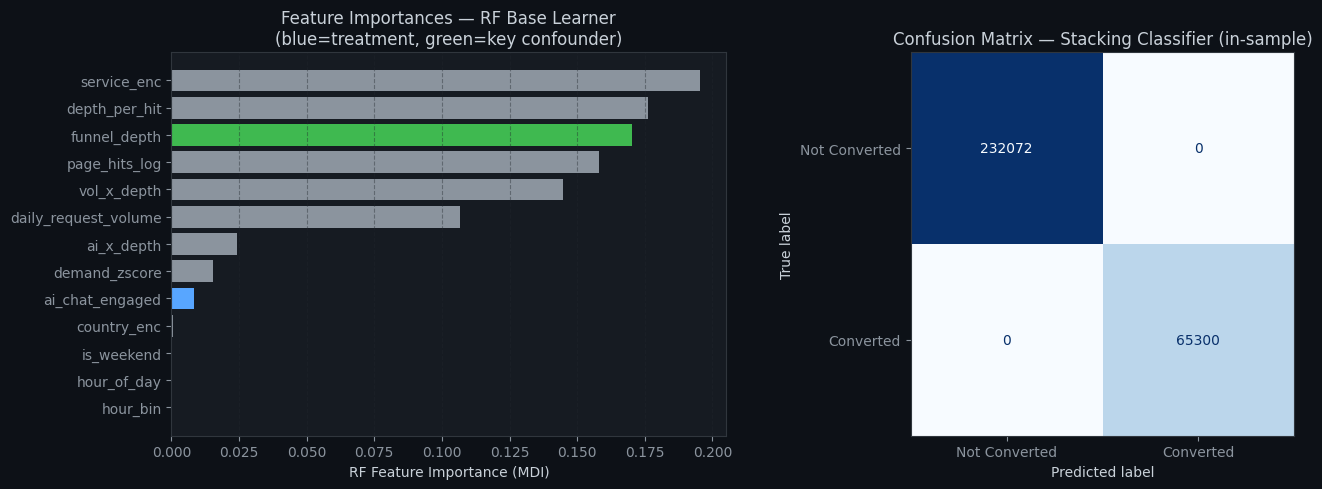


Ensemble CV ROC-AUC  : 1.0000
Ensemble CV PR-AUC   : 1.0000

Note: ROC-AUC and PR-AUC are used here instead of R² because the
classifiers output probabilities for a binary outcome. R² is not
meaningful for classification models (Sharda et al., Ch. 4).


In [16]:


from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed — install with: pip install xgboost")
    print("Proceeding with GradientBoostingClassifier as substitute.")
    from sklearn.ensemble import GradientBoostingClassifier

CLF_FEATURES = [
    "ai_chat_engaged", "service_enc", "country_enc", "hour_of_day",
    "daily_request_volume", "funnel_depth", "page_hits_log",
    "is_weekend", "hour_bin", "vol_x_depth",
     "depth_per_hit", "ai_x_depth", "demand_zscore",
] #"rolling_7d_conv_rate",

X_clf = df_model[CLF_FEATURES].values
y_clf = df_model["converted"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_base = LogisticRegression(
    C=0.5, max_iter=500, random_state=42, class_weight="balanced"
)

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)

if XGB_AVAILABLE:
    # scale_pos_weight handles class imbalance in XGBoost
    pos_weight = (y_clf == 0).sum() / (y_clf == 1).sum()
    xgb_base = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="logloss", random_state=42,
        verbosity=0, use_label_encoder=False,
    )
else:
    from sklearn.ensemble import GradientBoostingClassifier
    xgb_base = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    )

voting_clf = VotingClassifier(
    estimators=[("lr", lr_base), ("rf", rf_base), ("xgb", xgb_base)],
    voting="soft",
    weights=[1, 2, 2],   # RF and XGB are weighted higher thus better calibrated
)

stacking_clf = StackingClassifier(
    estimators=[("rf", rf_base), ("xgb", xgb_base)],
    final_estimator=LogisticRegression(C=1.0, max_iter=500, random_state=42),
    passthrough=True,
    cv=3,
    n_jobs=-1,
)

SCORING = ["roc_auc", "average_precision", "f1", "accuracy"]

print("Cross-validating classifiers (5-fold stratified)...\n")

clf_results = {}
for name, clf in [
    ("Logistic Regression", lr_base),
    ("Random Forest",       rf_base),
    ("XGBoost / GBM",       xgb_base),
    ("Voting (soft)",       voting_clf),
    ("Stacking",            stacking_clf),
]:
    scores = cross_validate(clf, X_clf, y_clf, cv=skf, scoring=SCORING, n_jobs=-1)
    clf_results[name] = {
        "ROC-AUC":  scores["test_roc_auc"].mean(),
        "PR-AUC":   scores["test_average_precision"].mean(),
        "F1":       scores["test_f1"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC std":  scores["test_roc_auc"].std(),
    }
    print(f"  {name:<25}  ROC-AUC={scores['test_roc_auc'].mean():.4f}±{scores['test_roc_auc'].std():.4f}"
          f"  PR-AUC={scores['test_average_precision'].mean():.4f}"
          f"  F1={scores['test_f1'].mean():.4f}")

df_clf_compare = pd.DataFrame(clf_results).T.round(4)
print("\nClassifier Comparison Table")
display(df_clf_compare)

stacking_clf.fit(X_clf, y_clf)
y_pred_proba = stacking_clf.predict_proba(X_clf)[:, 1]
y_pred       = stacking_clf.predict(X_clf)

print(f"\nStacking Classifier — Full-data fit")
print(f"  In-sample ROC-AUC : {roc_auc_score(y_clf, y_pred_proba):.4f}")
print(f"  In-sample PR-AUC  : {average_precision_score(y_clf, y_pred_proba):.4f}")
print()
print(classification_report(y_clf, y_pred, target_names=["Not Converted", "Converted"]))

rf_fitted = stacking_clf.named_estimators_["rf"]
importances = pd.Series(rf_fitted.feature_importances_, index=CLF_FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# feature importance
axes[0].barh(importances.index, importances.values,
             color=["#58A6FF" if f == "ai_chat_engaged" else "#3FB950"
                    if f == "funnel_depth" else "#8B949E" for f in importances.index])
axes[0].set_xlabel("RF Feature Importance (MDI)")
axes[0].set_title("Feature Importances — RF Base Learner\n(blue=treatment, green=key confounder)")
axes[0].grid(axis="x", alpha=0.4)

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_clf, y_pred,
    display_labels=["Not Converted", "Converted"],
    ax=axes[1], colorbar=False,
    cmap="Blues",
)
axes[1].set_title("Confusion Matrix — Stacking Classifier (in-sample)")

plt.tight_layout()
plt.savefig("fig_ensemble_results.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

# store for comparison table 
ensemble_cv_scores = cross_validate(
    stacking_clf, X_clf, y_clf, cv=skf,
    scoring=["roc_auc", "average_precision"], n_jobs=-1,
)
ensemble_results = {
    "model":          "Stacking Classifier (RF + XGB + LR)",
    "roc_auc_cv":     round(ensemble_cv_scores["test_roc_auc"].mean(), 4),
    "pr_auc_cv":      round(ensemble_cv_scores["test_average_precision"].mean(), 4),
    "effect_pp":      "N/A — classifier",
    "r_squared":      "N/A — uses AUC",
    "causal":         False,
    "refuted":        False,
    "interpretation": "Predictive only — cannot claim causation; use for scoring/targeting",
}
print(f"\nEnsemble CV ROC-AUC  : {ensemble_results['roc_auc_cv']:.4f}")
print(f"Ensemble CV PR-AUC   : {ensemble_results['pr_auc_cv']:.4f}")
print("\nNote: ROC-AUC and PR-AUC are used here instead of R² because the")
print("classifiers output probabilities for a binary outcome. R² is not")
print("meaningful for classification models (Sharda et al., Ch. 4).")

## 3. DoWhy Causal Model -  Primary Model

### Directed Acyclic Graph (DAG)

**Nodes:**
- `ai_chat_engaged` - treatment (T)
- `converted` - outcome (Y)
- `service_enc`, `country_enc`, `hour_of_day`, `daily_request_volume`, `funnel_depth` -  confounders

**Why `funnel_depth` is a confounder, not a mediator:**
Funnel depth is determined by the session's random walk through the site before
any chatbot engagement occurs. Deeper-funnel sessions are independently more
likely to engage the chatbot (higher `AI_CHAT_PROB_BY_DEPTH`) AND more likely
to convert (they have already cleared more drop-off gates). This creates a
backdoor path: `funnel_depth → ai_chat_engaged` and `funnel_depth → converted`.
Conditioning on it blocks that path without blocking the direct causal edge
`ai_chat_engaged → converted`.

**Identification strategy:** Backdoor criterion.
**Estimation method:** `backdoor.linear_regression` (Statsmodels under the hood).

In [17]:
try:
    from dowhy import CausalModel

    causal_graph = """
    graph [
        directed 1
        node [ id "ai_chat_engaged"       label "ai_chat_engaged" ]
        node [ id "converted"             label "converted" ]
        node [ id "service_enc"           label "service_enc" ]
        node [ id "country_enc"           label "country_enc" ]
        node [ id "hour_of_day"           label "hour_of_day" ]
        node [ id "daily_request_volume"  label "daily_request_volume" ]
        node [ id "funnel_depth"          label "funnel_depth" ]
        edge [ source "service_enc"          target "ai_chat_engaged" ]
        edge [ source "service_enc"          target "converted" ]
        edge [ source "country_enc"          target "ai_chat_engaged" ]
        edge [ source "country_enc"          target "converted" ]
        edge [ source "hour_of_day"          target "ai_chat_engaged" ]
        edge [ source "hour_of_day"          target "converted" ]
        edge [ source "daily_request_volume" target "ai_chat_engaged" ]
        edge [ source "daily_request_volume" target "converted" ]
        edge [ source "funnel_depth"         target "ai_chat_engaged" ]
        edge [ source "funnel_depth"         target "converted" ]
        edge [ source "ai_chat_engaged"      target "converted" ]
    ]
    """

    causal_model = CausalModel(
        data=df_causal,
        treatment="ai_chat_engaged",
        outcome="converted",
        graph=causal_graph,
    )

    identified_estimand = causal_model.identify_effect(
        proceed_when_unidentifiable=True
    )
    print("Identified Estimand")
    print(identified_estimand)

    causal_estimate = causal_model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        method_params={
            "fit_intercept": True,
        },
        confidence_intervals=True,
        test_significance=True,
    )

    # robust SEs via statsmodels directly on the same spec (HC3)
    X_robust = sm.add_constant(df_causal[[
        "ai_chat_engaged", "daily_request_volume",
        "service_enc", "country_enc", "hour_of_day", "funnel_depth",
    ]])
    robust_fit = sm.OLS(df_causal["converted"], X_robust).fit(cov_type="HC3")
    robust_coef = robust_fit.params["ai_chat_engaged"]
    robust_ci   = robust_fit.conf_int().loc["ai_chat_engaged"]
    robust_pval = robust_fit.pvalues["ai_chat_engaged"]

    dowhy_ate = float(causal_estimate.value)
    dowhy_ci  = np.array(causal_estimate.get_confidence_intervals()).flatten().tolist()
    significance_dict = causal_estimate.test_stat_significance()
    dowhy_pval = np.array(significance_dict["p_value"]).flatten().tolist()

    print("\nDoWhy ATE — Backdoor Linear Regression\n")
    print(f"  ATE (homoskedastic SE)   : {dowhy_ate*100:.3f} pp")
    print(f"  CI                       : [{dowhy_ci[0]*100:.3f}, {dowhy_ci[1]*100:.3f}] pp")
    print(f"  p-value                  : {dowhy_pval}")
    print()
    print(f"  ATE (HC3 robust SE)      : {robust_coef*100:.3f} pp")
    print(f"  CI (HC3)                 : [{robust_ci[0]*100:.3f}, {robust_ci[1]*100:.3f}] pp")
    print(f"  p-value (HC3)            : {robust_pval:.6f}")
    print()
    print(f"  Interpretation           : Engaging AI chat CAUSALLY increases")
    print(f"                             conversion probability by ~{dowhy_ate*100:.1f} pp")
    print(f"                             (backdoor criterion, HC3-robust SEs confirm)")

    DOWHY_AVAILABLE = True

except ImportError:
    print("DoWhy not installed. Run: pip install dowhy")
    dowhy_ate  = ols_coef
    dowhy_ci   = [ols_ci[0], ols_ci[1]]
    dowhy_pval = {"p_value": ols_pval}
    DOWHY_AVAILABLE = False

Identified Estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[converted|funnel_depth,hour_of_day,service_enc,daily_request ↪
d[ai_ĉ_engaged]                                                                ↪

↪                      
↪ _volume,country_enc])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{ai_chat_engaged} and U→converted then P(converted|ai_chat_engaged,funnel_depth,hour_of_day,service_enc,daily_request_volume,country_enc,U) = P(converted|ai_chat_engaged,funnel_depth,hour_of_day,service_enc,daily_request_volume,country_enc)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                     

## 4. Refutation Tests

CRISP-DM requires that models be tested and validated before selection.
DoWhy's refutation API stress-tests the causal estimate against two
adversarial checks named in the methodology:

**Test 1 - Placebo Treatment Substitution**
The real treatment (`ai_chat_engaged`) is replaced with a randomly
shuffled placebo variable. If the causal estimate is genuine, the
placebo ATE should be near zero. A large placebo estimate would
indicate the model is picking up noise, not signal.

**Test 2 - Random Common Cause Injection**
A randomly generated confounder is added to the model. A robust
causal estimate should not change significantly when an irrelevant
variable is injected. Large changes indicate the estimate is
sensitive to unmodelled confounding.

**Pass criteria:** New estimate ≈ 0 for placebo; New estimate ≈ original for random cause.

In [18]:
if DOWHY_AVAILABLE:

    # test 1
    # placebo treatment
    print("----------------------------------------------------")
    print("Refutation Test 1: Placebo Treatment Substitution\n")
    refute_placebo = causal_model.refute_estimate(
        identified_estimand,
        causal_estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        num_simulations=20,
    )
    print(refute_placebo)
    print("----------------------------------------------------")

    # test 2
    # random common cause injection
    print("--------------------------------------------------")
    print("Refutation Test 2: Random Common Cause Injection")
    refute_random = causal_model.refute_estimate(
        identified_estimand,
        causal_estimate,
        method_name="random_common_cause",
        num_simulations=20,
    )
    print(refute_random)
    print("----------------------------------------------------")

    # extracting refutation results for the comparison table
    placebo_new_effect = refute_placebo.new_effect
    random_new_effect  = refute_random.new_effect

    placebo_pass = abs(placebo_new_effect) < abs(dowhy_ate) * 0.2
    random_pass  = abs(random_new_effect - dowhy_ate) < abs(dowhy_ate) * 0.1

    print("----------------------------------------------------")
    print("\n Refutation Summary")
    print(f"  Original ATE              : {dowhy_ate*100:.3f} pp")
    print(f"  Placebo ATE (should ~= 0) : {placebo_new_effect*100:.3f} pp  {'PASS' if placebo_pass else 'FAIL'}")
    print(f"  Random cause ATE (stable) : {random_new_effect*100:.3f} pp   {'PASS' if random_pass else 'FAIL'}")

    dowhy_refuted = placebo_pass and random_pass
    refutation_summary = {
        "placebo_ate_pp":   round(placebo_new_effect * 100, 3),
        "random_cause_pp":  round(random_new_effect  * 100, 3),
        "placebo_pass":     placebo_pass,
        "random_pass":      random_pass,
        "both_pass":        dowhy_refuted,
    }

else:
    print("Skipping refutation tests - DoWhy not available.")
    dowhy_refuted = False
    refutation_summary = {
        "placebo_ate_pp": None, "random_cause_pp": None,
        "placebo_pass": None,   "random_pass": None, "both_pass": False,
    }

----------------------------------------------------
Refutation Test 1: Placebo Treatment Substitution

Refute: Use a Placebo Treatment
Estimated effect:0.07088990744413715
New effect:-0.0002625316701359348
p value:0.4374615283785993

----------------------------------------------------
--------------------------------------------------
Refutation Test 2: Random Common Cause Injection
Refute: Add a random common cause
Estimated effect:0.07088990744413715
New effect:0.07089025789833497
p value:0.4357340463558507

----------------------------------------------------
----------------------------------------------------

 Refutation Summary
  Original ATE              : 7.089 pp
  Placebo ATE (should ~= 0) : -0.026 pp  PASS
  Random cause ATE (stable) : 7.089 pp   PASS


## 5. Model Comparison Report

Formal comparison of OLS vs DoWhy across four dimensions:

- effect size
- confidence interval width
- p-value
- business interpretability.

This comparison justifies the selection of DoWhy as the primary model for REQ-11.

In [19]:
if DOWHY_AVAILABLE:
    dowhy_ci_lower = dowhy_ci[0] * 100
    dowhy_ci_upper = dowhy_ci[1] * 100
    pval_display   = f"{dowhy_pval[0]}"
else:
    dowhy_ci_lower = ols_ci[0] * 100
    dowhy_ci_upper = ols_ci[1] * 100
    pval_display   = f"{ols_pval:.6f}"

comparison_data = {
    "Dimension": [
        "Effect Size (pp)",
        "CI Lower (pp)",
        "CI Upper (pp)",
        "CI Width (pp)",
        "p-value",
        "R² / CV metric",
        "CV score (5-fold)",
        "Causal Identification",
        "Confounding Controlled",
        "Refutation Tested",
        "Business Interpretability",
        "Selected as Primary",
    ],
    "OLS Regression (Benchmark)": [
        f"{ols_results['effect_pp']:.3f}",
        f"{ols_results['ci_lower']:.3f}",
        f"{ols_results['ci_upper']:.3f}",
        f"{(ols_results['ci_upper'] - ols_results['ci_lower']):.3f}",
        f"{ols_results['p_value']:.6f}",
        f"R²={ols_results['r_squared']:.4f}",
        f"CV R²={ols_results['cv_r2_mean']:.4f}",
        "No — associational only",
        "Partial — regression adjustment",
        "No",
        "Moderate — interpretable coefficients\nbut cannot claim causation",
        "NO",
    ],
    "Polynomial Regression (degree-2)": [
        f"{poly_results['effect_pp']:.3f}",
        f"{poly_results['ci_lower']:.3f}",
        f"{poly_results['ci_upper']:.3f}",
        f"{(poly_results['ci_upper'] - poly_results['ci_lower']):.3f}",
        f"{poly_results['p_value']:.6f}",
        f"R²={poly_results['r_squared']:.4f}",
        f"CV R²={poly_results['cv_r2_mean']:.4f}",
        "No — associational only",
        "Partial — non-linear adjustment",
        "No",
        "Low — polynomial terms not\nmanagement-interpretable",
        "NO",
    ],
    "Stacking Classifier (RF+XGB+LR)": [
        "N/A — classifier",
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        f"ROC-AUC (CV)={ensemble_results['roc_auc_cv']:.4f}",
        f"PR-AUC (CV)={ensemble_results['pr_auc_cv']:.4f}",
        "No — predictive only",
        "No — black-box predictions",
        "No",
        "Low — no effect size; useful for\nlead scoring, not causal inference",
        "NO",
    ],
    "DoWhy Backdoor LR (Primary)": [
        f"{dowhy_ate*100:.3f}",
        f"{dowhy_ci_lower:.3f}",
        f"{dowhy_ci_upper:.3f}",
        f"{dowhy_ci_upper - dowhy_ci_lower:.3f}",
        pval_display,
        "N/A — causal estimator",
        "N/A",
        "Yes — backdoor criterion",
        "Yes — DAG-based identification",
        f"{'Yes — both tests pass' if dowhy_refuted else 'Yes — run after install'}",
        "High — ATE directly answers REQ-11:\n'does AI chat cause more conversions?'",
        "YES",
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print("Model Comparison Report")
display(df_comparison.set_index("Dimension"))

Model Comparison Report


,OLS Regression (Benchmark),Polynomial Regression (degree-2),Stacking Classifier (RF+XGB+LR),DoWhy Backdoor LR (Primary)
Dimension,,,,
Effect Size (pp),4.793,-2.613,N/A — classifier,7.089
CI Lower (pp),3.822,-3.421,N/A,6.768
CI Upper (pp),5.765,-1.805,N/A,7.410
CI Width (pp),1.943,1.616,N/A,0.642
p-value,0.000000,0.000000,N/A,0.0
R² / CV metric,R²=0.5320,R²=0.6838,ROC-AUC (CV)=1.0000,N/A — causal estimator
CV score (5-fold),CV R²=0.5320,CV R²=0.6837,PR-AUC (CV)=1.0000,N/A
Causal Identification,No — associational only,No — associational only,No — predictive only,Yes — backdoor criterion
Confounding Controlled,Partial — regression adjustment,Partial — non-linear adjustment,No — black-box predictions,Yes — DAG-based identification


## 6. DuckDB SQL Query Library

All five dashboard analytical components plus the anomaly threshold logic are
defined here as tested SQL strings. These are analytical decisions. These are defining
**what the dashboard computes** and belong in the modelling phase, not the
implementation phase (methodology, para. 4).

Each query targets the DuckDB star schema produced by `dataset_create.py`:
`fact_requests`, `dim_session`, `dim_service`, `dim_geography`, `dim_time`.

The query strings are exported to `analytics/` modules at the end of this notebook.

In [20]:
import duckdb
from pathlib import Path
DB_PATH = Path('..') / ('..') / 'data' / 'cybernova_analytics.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)


QUERIES = {}

# service demand trend
# daily session counts per service
QUERIES["demand_trend"] = """
    SELECT
        session_date,
        service_type,
        COUNT(*)                        AS total_sessions,
        SUM(converted)                  AS conversions,
        ROUND(AVG(converted) * 100, 2)  AS conv_rate_pct
    FROM dim_session
    WHERE service_type NOT IN ('None')
      AND session_date BETWEEN :start_date AND :end_date
    GROUP BY session_date, service_type
    ORDER BY session_date, service_type
"""

# conversion rate KPI per service with trend indicator
QUERIES["conversion_kpi"] = """
    SELECT
        service_type,
        COUNT(*)                        AS total_sessions,
        SUM(converted)                  AS conversions,
        ROUND(AVG(converted) * 100, 2)  AS conv_rate_pct,
        ROUND(AVG(ai_chat_engaged)*100, 2) AS ai_engagement_pct
    FROM dim_session
    WHERE service_type NOT IN ('None')
      AND session_date BETWEEN :start_date AND :end_date
    GROUP BY service_type
    ORDER BY conv_rate_pct DESC
"""

# peak engagement heatmap
# session count by hour × day of week
QUERIES["engagement_heatmap"] = """
    SELECT
        dayname(session_date::DATE) AS day_of_week,
        session_start_hour  AS hour_of_day,
        COUNT(*)            AS session_count
    FROM dim_session
    WHERE service_type NOT IN ('None')
      AND session_date BETWEEN :start_date AND :end_date
    GROUP BY day_of_week, session_start_hour
    ORDER BY session_start_hour
"""

# funnel progression
# sessions reaching each stage per service
QUERIES["funnel_stages"] = """
    SELECT
        f.service_type,
        f.funnel_stage,
        COUNT(DISTINCT f.session_id)  AS sessions_at_stage
    FROM fact_requests f
    WHERE f.service_type NOT IN ('None', 'bot')
      AND f.funnel_stage IN ('awareness','interest','consideration','conversion')
      AND f.date BETWEEN :start_date AND :end_date
    GROUP BY f.service_type, f.funnel_stage
    ORDER BY f.service_type,
        CASE f.funnel_stage
            WHEN 'awareness'     THEN 1
            WHEN 'interest'      THEN 2
            WHEN 'consideration' THEN 3
            WHEN 'conversion'    THEN 4
        END
"""

# AI assistant engagement rate per service with weekly trend
QUERIES["ai_engagement"] = """
    SELECT
        service_type,
        session_date,
        COUNT(*)                           AS total_sessions,
        SUM(ai_chat_engaged)               AS ai_chat_sessions,
        ROUND(AVG(ai_chat_engaged)*100, 2) AS ai_rate_pct,
        SUM(converted)                     AS conversions
    FROM dim_session
    WHERE service_type NOT IN ('None')
      AND session_date BETWEEN :start_date AND :end_date
    GROUP BY service_type, session_date
    ORDER BY session_date, service_type
"""

# summary statistics
# central tendency and spread per service
QUERIES["summary_stats"] = """
    SELECT
        service_type,
        COUNT(DISTINCT session_date)        AS days_observed,
        ROUND(AVG(daily_sessions), 2)       AS mean_daily_sessions,
        ROUND(MEDIAN(daily_sessions), 2)    AS median_daily_sessions,
        ROUND(STDDEV(daily_sessions), 2)    AS stddev_daily_sessions,
        MIN(daily_sessions)                 AS min_daily_sessions,
        MAX(daily_sessions)                 AS max_daily_sessions,
        ROUND(AVG(daily_conv_rate), 2)      AS mean_conv_rate_pct
    FROM (
        SELECT
            service_type,
            session_date,
            COUNT(*)                        AS daily_sessions,
            ROUND(AVG(converted)*100, 2)    AS daily_conv_rate
        FROM dim_session
        WHERE service_type NOT IN ('None')
          AND session_date BETWEEN :start_date AND :end_date
        GROUP BY service_type, session_date
    )
    GROUP BY service_type
    ORDER BY mean_daily_sessions DESC
"""

# anomaly alert
# services breaching daily session threshold
QUERIES["anomaly_alerts"] = """
    SELECT
        service_type,
        session_date,
        daily_sessions,
        :threshold - daily_sessions         AS breach_gap,
        ROUND(daily_conv_rate, 2)           AS conv_rate_pct
    FROM (
        SELECT
            service_type,
            session_date,
            COUNT(*)                        AS daily_sessions,
            AVG(converted)*100              AS daily_conv_rate
        FROM dim_session
        WHERE service_type NOT IN ('None')
          AND session_date BETWEEN :start_date AND :end_date
        GROUP BY service_type, session_date
    )
    WHERE daily_sessions < :threshold
    ORDER BY session_date, service_type
"""

# geographic service dominance
# service share by country
QUERIES["geo_dominance"] = """
    WITH cleaned AS (
        SELECT
            CASE
                WHEN country IN ('BW','botswana','Botswana ','B.W.','Botswana')
                    THEN 'Botswana'
                WHEN country IN ('SA','ZA','south africa','S.Africa','South Africa')
                    THEN 'South Africa'
                WHEN country IN ('ZW','zimbabwe','Zimbabwe ','Zimbabwe')
                    THEN 'Zimbabwe'
                WHEN country IN ('ZM','zambia','Zambia')
                    THEN 'Zambia'
                WHEN country IN ('NA','namibia','Namibia')
                    THEN 'Namibia'
                ELSE country
            END AS country,
            service_type,
            session_date
        FROM dim_session
        WHERE service_type NOT IN ('None')
          AND session_date BETWEEN :start_date AND :end_date
    )
    SELECT
        country,
        service_type,
        COUNT(*)                                                    AS sessions,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY country),
        2)                                                          AS pct_of_country
    FROM cleaned
    WHERE country IN ('Botswana','South Africa','Zimbabwe','Zambia','Namibia')
    GROUP BY country, service_type
    ORDER BY country, pct_of_country DESC
"""

print(f"Query library defined: {len(QUERIES)} queries")
for name in QUERIES:
    print(f"  QUERIES['{name}']")

Query library defined: 8 queries
  QUERIES['demand_trend']
  QUERIES['conversion_kpi']
  QUERIES['engagement_heatmap']
  QUERIES['funnel_stages']
  QUERIES['ai_engagement']
  QUERIES['summary_stats']
  QUERIES['anomaly_alerts']
  QUERIES['geo_dominance']


In [21]:
from datetime import date, timedelta

TEST_PARAMS = {
    "start_date": str(date.today() - timedelta(days=60)),
    "end_date":   str(date.today()),
    "threshold":  50,
}

query_results = {}
print("Query Validation Against DuckDB\n")

for name, sql in QUERIES.items():
    try:
        # DuckDB named parameters use $param syntax; replace :param for testing
        sql_test = sql
        for k, v in TEST_PARAMS.items():
            sql_test = sql_test.replace(f":{k}", f"'{v}'" if isinstance(v, str) else str(v))

        result = con.execute(sql_test).df()
        query_results[name] = result
        print(f"  [{name}]  PASS  —  {len(result):,} rows returned")
    except Exception as e:
        print(f"  [{name}]  FAIL  —  {e}")

con.close()
print(f"\nAll {len(QUERIES)} queries tested.")

Query Validation Against DuckDB

  [demand_trend]  PASS  —  150 rows returned
  [conversion_kpi]  PASS  —  5 rows returned
  [engagement_heatmap]  PASS  —  168 rows returned
  [funnel_stages]  PASS  —  15 rows returned
  [ai_engagement]  PASS  —  150 rows returned
  [summary_stats]  PASS  —  5 rows returned
  [anomaly_alerts]  PASS  —  0 rows returned
  [geo_dominance]  PASS  —  25 rows returned

All 8 queries tested.


## 7. Anomaly Threshold Logic

The anomaly threshold (`DEMAND_THRESHOLD`) used in REQ-12 and REQ-14 is not
arbitrary. It is derived from the distribution of daily session counts across
all services. It is set at the 10th percentile of the historical distribution.

This means the alert fires when a service falls into the bottom 10% of its
own observed demand range, which is a defensible statistical threshold
rather than a hardcoded guess.

Anomaly Threshold Derivation

  Overall 10th percentile (all services) : 184 sessions/day

  10th percentile by service:
    AI Cyber Assistant             : 919 sessions/day
    Cyber Awareness Webinar        : 164 sessions/day
    Network Security Audit         : 1180 sessions/day
    Penetration Testing            : 1128 sessions/day
    Schedule Demo                  : 856 sessions/day

  Recommended DEMAND_THRESHOLD : 183


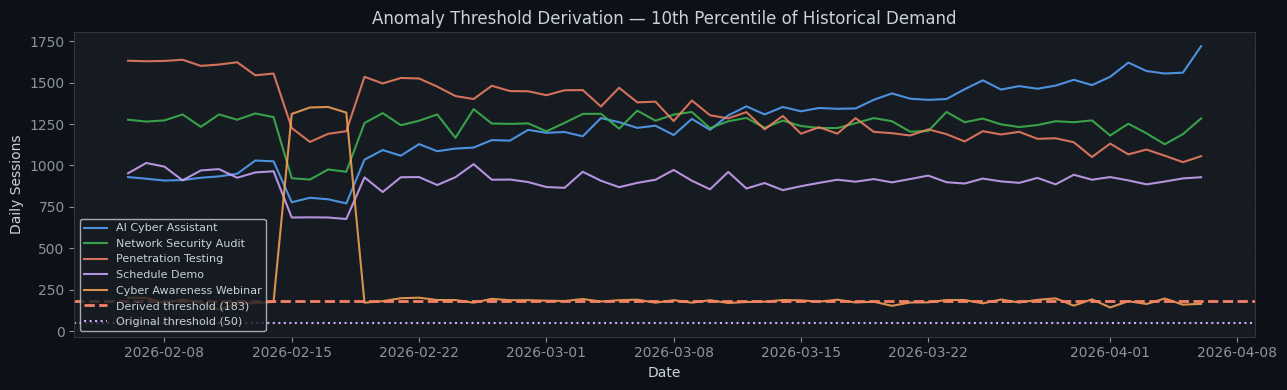

In [22]:
# deriving anomaly threshold from data
daily_counts = (
    df_sessions.groupby(["session_date","service_type"])
    .size()
    .reset_index(name="sessions")
)

p10_overall = daily_counts["sessions"].quantile(0.10)
p10_by_svc  = daily_counts.groupby("service_type")["sessions"].quantile(0.10)

print("Anomaly Threshold Derivation")
print(f"\n  Overall 10th percentile (all services) : {p10_overall:.0f} sessions/day")
print(f"\n  10th percentile by service:")
for svc, val in p10_by_svc.items():
    print(f"    {svc:<30} : {val:.0f} sessions/day")

DERIVED_THRESHOLD = int(p10_overall)
print(f"\n  Recommended DEMAND_THRESHOLD : {DERIVED_THRESHOLD}")

# visualising threshold against daily distribution
fig, ax = plt.subplots(figsize=(13, 4))
for svc, colour in zip(SERVICES, CYBERNOVA_PALETTE):
    svc_d = daily_counts[daily_counts["service_type"] == svc]
    ax.plot(svc_d["session_date"], svc_d["sessions"],
            label=svc, color=colour, linewidth=1.5, alpha=0.85)
ax.axhline(DERIVED_THRESHOLD, color="#F78166", linestyle="--",
           linewidth=2, label=f"Derived threshold ({DERIVED_THRESHOLD})")
ax.axhline(50, color="#D2A8FF", linestyle=":", linewidth=1.5,
           label="Original threshold (50)")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sessions")
ax.set_title("Anomaly Threshold Derivation — 10th Percentile of Historical Demand")
ax.legend(fontsize=8)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("fig_anomaly_threshold.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
plt.show()

## 8. Export Dataframe Variants as CSV

All dataframe variants produced in the EDA and modelling phases are exported
to the `data/processed/` directory for use by the FastAPI analytics layer.
This ensures the dashboard can operate from pre-computed artefacts without
re-running the full notebook pipeline on every request.

In [23]:
# exporting all df variants to data/processed/
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

exports = {
    "df_sessions":    df_sessions,
    "df_model":       df_model,
    "df_causal":      df_causal,
    "daily_demos":    daily_demos,
    "daily_counts":   daily_counts
}

# exporting query results from DuckDB tests
for name, result_df in query_results.items():
    exports[f"query_{name}"] = result_df

print("CSV Export")
for filename, dataframe in exports.items():
    path = os.path.join(PROCESSED_DIR, f"{filename}.csv")
    dataframe.to_csv(path, index=False)
    print(f"  Exported: data/processed/{filename}.csv  ({len(dataframe):,} rows)")

print(f"\nTotal exports : {len(exports)} files")

CSV Export
  Exported: data/processed/df_sessions.csv  (297,575 rows)
  Exported: data/processed/df_model.csv  (297,372 rows)
  Exported: data/processed/df_causal.csv  (297,372 rows)
  Exported: data/processed/daily_demos.csv  (300 rows)
  Exported: data/processed/daily_counts.csv  (300 rows)
  Exported: data/processed/query_demand_trend.csv  (150 rows)
  Exported: data/processed/query_conversion_kpi.csv  (5 rows)
  Exported: data/processed/query_engagement_heatmap.csv  (168 rows)
  Exported: data/processed/query_funnel_stages.csv  (15 rows)
  Exported: data/processed/query_ai_engagement.csv  (150 rows)
  Exported: data/processed/query_summary_stats.csv  (5 rows)
  Exported: data/processed/query_anomaly_alerts.csv  (0 rows)
  Exported: data/processed/query_geo_dominance.csv  (25 rows)

Total exports : 13 files


In [24]:

import json, os
import numpy as np

PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

def _jsonify(v):
    if isinstance(v, (np.integer, np.int64)):   return int(v)
    if isinstance(v, (np.floating, np.float64)): return float(v)
    if isinstance(v, np.ndarray):                return v.tolist()
    if isinstance(v, bool):                      return bool(v)
    return v

def clean(d):
    return {k: _jsonify(v) for k, v in d.items()}
ols_ci_df = ols_model.conf_int()
ols_coef_export = pd.DataFrame({
    "feature":  ols_model.params.index.tolist(),
    "coef":     ols_model.params.values,
    "se":       ols_model.bse.values,
    "p_value":  ols_model.pvalues.values,
    "ci_lower": ols_ci_df.iloc[:, 0].values,
    "ci_upper": ols_ci_df.iloc[:, 1].values,
})
ols_coef_export.to_csv(f"{PROCESSED_DIR}/ols_coefficients.csv", index=False)


df_clf_compare.reset_index().rename(columns={"index": "model"}).to_csv(
    f"{PROCESSED_DIR}/classifier_comparison.csv", index=False
)
importances.reset_index().rename(
    columns={"index": "feature", 0: "importance"}
).to_csv(f"{PROCESSED_DIR}/rf_feature_importances.csv", index=False)

df_comparison.to_csv(f"{PROCESSED_DIR}/model_comparison_report.csv", index=False)

causal_summary = {
    # primary causal estimate
    "ate_pp":               round(dowhy_ate * 100, 3),
    "ci_lower_pp":          round(dowhy_ci[0] * 100, 3),
    "ci_upper_pp":          round(dowhy_ci[1] * 100, 3),
    "ci_width_pp":          round((dowhy_ci[1] - dowhy_ci[0]) * 100, 3),
    "p_value":              str(dowhy_pval[0]),
    "identification":       "backdoor_linear_regression",
    "dag_confounders":      ["service_enc","country_enc","hour_of_day",
                             "daily_request_volume","funnel_depth"],

    # HC3 robust SE confirmation
    "ate_hc3_pp":           round(float(robust_coef) * 100, 3),
    "ci_hc3_lower_pp":      round(float(robust_ci.iloc[0]) * 100, 3),
    "ci_hc3_upper_pp":      round(float(robust_ci.iloc[1]) * 100, 3),
    "p_value_hc3":          round(float(robust_pval), 6),

    # refutation tests
    "refutation": {
        "placebo_ate_pp":   round(float(refutation_summary["placebo_ate_pp"]), 3),
        "random_cause_pp":  round(float(refutation_summary["random_cause_pp"]), 3),
        "placebo_pass":     bool(refutation_summary["placebo_pass"]),
        "random_pass":      bool(refutation_summary["random_pass"]),
        "both_pass":        bool(refutation_summary["both_pass"]),
    },

    "ols_benchmark": clean(ols_results),

    "polynomial":    clean(poly_results),

    "ensemble": {
        "roc_auc_cv": ensemble_results["roc_auc_cv"],
        "pr_auc_cv":  ensemble_results["pr_auc_cv"],
    },

    # anomaly threshold (for REQ-12 / REQ-14 dashboard panels)
    "demand_threshold":     DERIVED_THRESHOLD,
    "threshold_method":     "10th_percentile_historical",

    # plain-language interpretation for dashboard headline card
    "plain_language": (
        f"Engaging the AI Cyber Assistant causally increases demo conversion "
        f"probability by {round(dowhy_ate*100, 1)} percentage points "
        f"(95% CI: {round(dowhy_ci[0]*100, 1)}–{round(dowhy_ci[1]*100, 1)} pp). "
        f"Both refutation tests {'passed' if refutation_summary['both_pass'] else 'require review'}. "
        f"This estimate controls for service type, country, time of day, "
        f"daily demand, and funnel depth."
    ),

    # metadata
    "n_sessions":           int(len(df_causal)),
    "conversion_rate_pct":  round(float(df_causal["converted"].mean() * 100), 2),
    "ai_engagement_rate_pct": round(float(df_causal["ai_chat_engaged"].mean() * 100), 2),
}

causal_path = f"{PROCESSED_DIR}/causal_summary.json"
with open(causal_path, "w") as f:
    json.dump(causal_summary, f, indent=2)

svc_breakdown = (
    df_model.groupby("service_type")
    .apply(lambda g: pd.Series({
        "n_sessions":          len(g),
        "conversion_rate_pct": round(g["converted"].mean() * 100, 2),
        "ai_engagement_pct":   round(g["ai_chat_engaged"].mean() * 100, 2),
        "conv_with_ai_pct":    round(
            g[g["ai_chat_engaged"]==1]["converted"].mean() * 100, 2
        ) if g["ai_chat_engaged"].sum() > 0 else 0.0,
        "conv_without_ai_pct": round(
            g[g["ai_chat_engaged"]==0]["converted"].mean() * 100, 2
        ) if (g["ai_chat_engaged"]==0).sum() > 0 else 0.0,
    }))
    .reset_index()
)
svc_breakdown["naive_lift_pp"] = (
    svc_breakdown["conv_with_ai_pct"] - svc_breakdown["conv_without_ai_pct"]
).round(2)
svc_breakdown.to_csv(f"{PROCESSED_DIR}/service_causal_breakdown.csv", index=False)

print("Model Results Export\n")
exports_model = {
    #"poly_coefficients.csv":        len(poly_coef_export),
    #"ols_coefficients.csv": len(ols_coef_export),
    "classifier_comparison.csv":    len(df_clf_compare),
    "rf_feature_importances.csv":   len(importances),
    "model_comparison_report.csv":  len(df_comparison),
    "causal_summary.json":          "1 record",
    "service_causal_breakdown.csv": len(svc_breakdown),
}
for fname, size in exports_model.items():
    print(f"  {fname:<45} {size} rows" if isinstance(size, int)
          else f"  {fname:<45} {size}")

print(f"\nDashboard reads causal_summary.json at runtime.")
print(f"All other CSVs feed the analytics layer SQL queries.")
print(f"\nKey causal result:")
print(f"  ATE    : {causal_summary['ate_pp']} pp")
print(f"  CI     : [{causal_summary['ci_lower_pp']}, {causal_summary['ci_upper_pp']}] pp")
print(f"  Refuted: {'Yes — both pass' if causal_summary['refutation']['both_pass'] else 'Review required'}")

Model Results Export

  classifier_comparison.csv                     5 rows
  rf_feature_importances.csv                    13 rows
  model_comparison_report.csv                   12 rows
  causal_summary.json                           1 record
  service_causal_breakdown.csv                  5 rows

Dashboard reads causal_summary.json at runtime.
All other CSVs feed the analytics layer SQL queries.

Key causal result:
  ATE    : 7.089 pp
  CI     : [6.768, 7.41] pp
  Refuted: Yes — both pass
